In [1]:
# Load packages
library(dplyr)
library(tidyr)
library(hms)
library(lubridate)
library(ggplot2)
library(purrr)
library(tidyverse)
library(cowplot)
library(readr)
library(patchwork)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘lubridate’


The following object is masked from ‘package:hms’:

    hms


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats 1.0.0     ✔ stringr 1.5.1
✔ readr   2.1.5     ✔ tibble  3.2.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter()  masks stats::filter()
✖ lubridate::hms() masks hms::hms()
✖ dplyr::lag()     masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘cowplot’


The following object is masked from ‘package:lubridate’:

    stamp



Attaching package: ‘patchwork’


The following object is

In [2]:
getwd()

[1] "/home/strawberry/Downloads"

In [17]:
od_tp <- read_tsv("od600_anox_080726.tsv")
head(od_tp)
tail(od_tp)

Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”
Rows: 23 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): Strain, Carbon
dbl (3): OD600, Time_hr, Replicate

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Strain,Carbon,OD600,Time_hr,Replicate
<chr>,<chr>,<dbl>,<dbl>,<dbl>
ATCC_43300,M9_GLU,0.030,0,1
ATCC_43300,M9_GLU,0.020,0,2
ATCC_43300,M9_GLU,0.030,0,3
ATCC_43300,M9_SIA,0.038,0,1
ATCC_43300,M9_SIA,0.032,0,2
ATCC_43300,M9_SIA,0.030,0,3


Strain,Carbon,OD600,Time_hr,Replicate
<chr>,<chr>,<dbl>,<dbl>,<dbl>
ATCC_43300,M9_GMP,0.091,24,1
ATCC_43300,M9_GMP,0.095,24,2
ATCC_43300,M9_GMP,0.108,24,3
ATCC_43300,M9,0.067,24,1
ATCC_43300,M9,0.038,24,2
ATCC_43300,M9,0.030,24,3


`geom_smooth()` using formula = 'y ~ x'
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“pseudoinverse used at -0.12”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“neighborhood radius 24.12”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“reciprocal condition number  0”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“There are other near singularities as well. 581.77”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“pseudoinverse used at -0.12”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“neighborhood radius 24.12”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“reciprocal condition number  0”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“Ther

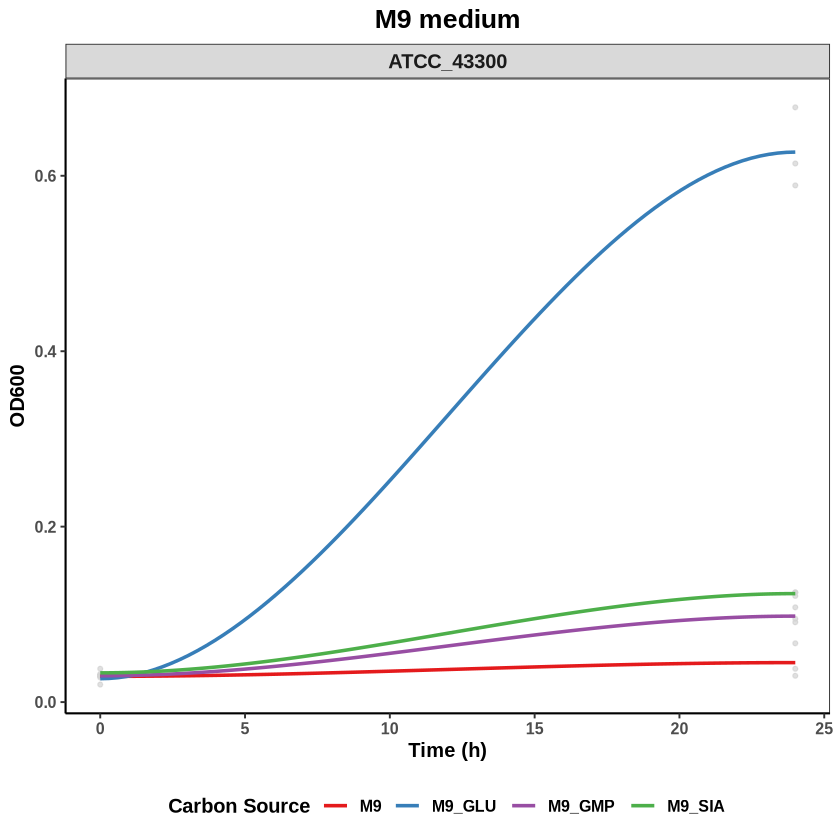

In [18]:
plotA <- ggplot(
  od_tp %>%
    filter(!is.na(Carbon), Carbon != "Blank"),
  aes(
    x = Time_hr,
    y = OD600,
    color = Carbon,
    group = Carbon
  )
) +
 #  geom_line(linewidth = 1.2) +
 #  geom_point(size = 3) +
 # Raw measurements in light gray
  geom_point(
    aes(group = interaction(Strain, Carbon)),
    color = "lightgray",
    size = 1.0,
    alpha = 0.7
  ) +
  # Loess trend colored by Carbon source
  geom_smooth(
    aes(color = Carbon, group = Carbon),
    method = "loess",
    span = 1,
    se = FALSE,
    linewidth = 1, 
    na.rm = TRUE
  ) +
  facet_wrap(~ Strain) +
  scale_color_manual(
  values = c(
    "M9"       = "#E41A1C",
    "M9_GLU"  = "#377EB8",
    "M9_SIA"   = "#4DAF4A",
    "M9_GMP"      = "#984EA3"
  )
) +  labs(
    x = "Time (h)",
    y = "OD600", 
    color = "Carbon Source",
    title = "M9 medium"
  ) +
  theme_bw(base_size = 12) +
 theme(
  text = element_text(face = "bold"),
  panel.grid = element_blank(),
  axis.line = element_line(color = "black"),
  legend.position = "bottom",
  plot.title = element_text(size = 16, hjust = 0.5),
  strip.text = element_text(size = 12)
)

plotA

In [8]:
ggsave("m9_anox_080726.png")

Saving 7 x 7 in image
`geom_smooth()` using formula = 'y ~ x'
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“pseudoinverse used at -0.12”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“neighborhood radius 24.12”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“reciprocal condition number  0”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“There are other near singularities as well. 581.77”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“pseudoinverse used at -0.12”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“neighborhood radius 24.12”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“reciprocal condition number  0”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric

In [20]:
glimpse(od_tp)

Rows: 126
Columns: 4
$ Time_hr <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ Strain  <chr> "ATCC_29213", "ATCC_29213", "ATCC_29213", "ATCC_29213", "ATCC_…
$ Carbon  <fct> M9, M9, M9, M9_GLU, M9_GLU, M9_GLU, M9_Neu5Ac, M9_Neu5Ac, M9_N…
$ OD600   <dbl> 0.03, 0.04, 0.04, 0.05, 0.04, 0.05, 0.03, 0.02, 0.04, 0.03, 0.…


In [23]:
od_tp <- od_tp %>%
  group_by(Strain, Carbon, Time_hr) %>%
  mutate(
    Replicate = row_number()
  ) %>%
  ungroup()

od_tp %>%
  filter(Strain == "ATCC_29213",
         Carbon == "M9")

Time_hr,Strain,Carbon,OD600,Replicate
<dbl>,<chr>,<fct>,<dbl>,<int>
0,ATCC_29213,M9,0.03,1
0,ATCC_29213,M9,0.04,2
0,ATCC_29213,M9,0.04,3
6,ATCC_29213,M9,0.72,1
6,ATCC_29213,M9,0.63,2
6,ATCC_29213,M9,0.63,3
24,ATCC_29213,M9,1.92,1
24,ATCC_29213,M9,1.88,2
24,ATCC_29213,M9,1.76,3


In [64]:
# Explore growth rates to assess carbohydrate catabolism

In [24]:
growth_rates <- od_tp %>%
  group_by(Strain, Carbon, Replicate) %>%
  summarise(

    mu = coef(
      lm(log(OD600) ~ Time_hr)
    )[2],

    mu_0_6 =
      (log(OD600[Time_hr == 6]) -
       log(OD600[Time_hr == 0])) / 6,

    mu_6_24 =
      (log(OD600[Time_hr == 24]) -
       log(OD600[Time_hr == 6])) / 18,

    mu_max = max(mu_0_6, mu_6_24),

    delta_OD =
      OD600[Time_hr == 24] -
      OD600[Time_hr == 0],

    fold_change =
      OD600[Time_hr == 24] /
      OD600[Time_hr == 0],

    .groups = "drop"
  )
head(growth_rates)

Strain,Carbon,Replicate,mu,mu_0_6,mu_6_24,mu_max,delta_OD,fold_change
<chr>,<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
11.1.1,M9,1,0.09351309,0.1831020,0.07218239,0.1831020,0.40,11.00000
11.1.1,M9,2,0.10478155,0.2789961,0.06330190,0.2789961,0.47,16.66667
11.1.1,M9,3,0.10638048,0.3243184,0.05449051,0.3243184,0.53,18.66667
11.1.1,M9_GLU,1,0.08599327,0.2443895,0.04827988,0.2443895,0.56,10.33333
11.1.1,M9_GLU,2,0.09059949,0.3093830,0.03850818,0.3093830,0.59,12.80000
11.1.1,M9_GLU,3,0.08657370,0.3076378,0.03393939,0.3076378,0.64,11.66667


In [53]:
colnames(growth_rates)

[1] "Strain"      "Carbon"      "Replicate"   "mu"          "mu_0_6"     
[6] "mu_6_24"     "mu_max"      "delta_OD"    "fold_change"

In [55]:
# Compute summary stats for growth rates 
metrics <- c(
  "mu",
  "mu_0_6",
  "mu_6_24",
  "mu_max",
  "delta_OD",
  "fold_change"
)

summary_long <- growth_rates %>%
  pivot_longer(
    cols = all_of(metrics),
    names_to = "Metric",
    values_to = "Value"
  ) %>%
  group_by(Strain, Carbon, Metric) %>%
  summarise(
    mean = mean(Value),
    sd   = sd(Value),
    sem  = sd(Value) / sqrt(n()),
    n    = n(),
    .groups = "drop"
  )

head(summary_long)

Strain,Carbon,Metric,mean,sd,sem,n
<chr>,<fct>,<chr>,<dbl>,<dbl>,<dbl>,<int>
11.1.1,M9,delta_OD,0.46666667,0.065064071,0.037564759,3
11.1.1,M9,fold_change,15.44444444,3.976784482,2.295997591,3
11.1.1,M9,mu,0.10155838,0.007013137,0.004049037,3
11.1.1,M9,mu_0_6,0.26213883,0.072101572,0.041627862,3
11.1.1,M9,mu_6_24,0.06332494,0.008845959,0.005107217,3
11.1.1,M9,mu_max,0.26213883,0.072101572,0.041627862,3


In [58]:
# Define function to plot all metrics, one per plot 
library(dplyr)
library(ggplot2)

plot_single_metric <- function(summary_long, raw_data, metric_name) {
  
  # filter summary for one metric
  df_sum <- summary_long %>%
    filter(Metric == metric_name)
  
  # reshape raw data for that metric only
  df_raw <- raw_data %>%
    select(Strain, Carbon, all_of(metric_name)) %>%
    rename(Value = all_of(metric_name))
  
  ggplot(df_sum, aes(x = Carbon, y = mean, fill = Carbon)) +
    
    geom_col(
      color = "black",
      width = 0.75,
      linewidth = 0.6
    ) +
    
    geom_errorbar(
      aes(
        ymin = mean - sd,
        ymax = mean + sd
      ),
      width = 0.15,
      linewidth = 0.8
    ) +
    
    geom_jitter(
      data = df_raw,
      aes(x = Carbon, y = Value),
      width = 0.08,
      size = 2.3,
      shape = 21,
      fill = "white",
      color = "black"
    ) +
    
    facet_wrap(~Strain, ncol = 2) +
    
    scale_fill_manual(values = c(
      "M9" = "#E41A1C",
      "M9_GLU" = "#377EB8",
      "M9_Neu5Ac" = "#4DAF4A",
      "M9_GMP" = "#984EA3"
    )) +
    
    labs(
      title = paste("Growth metric:", metric_name),
      x = "Condition",
      y = metric_name,
      fill = "Carbon Source"
    ) +
    
    theme_bw(base_size = 14) +
    theme(
      plot.title = element_text(size = 18, face = "bold", hjust = 0.5),
      strip.text = element_text(size = 14, face = "bold"),
      axis.title = element_text(size = 14, face = "bold"),
      axis.text = element_text(size = 12, face = "bold", colour = "black"),
      axis.text.x = element_text(angle = 45, hjust = 1),
      legend.title = element_text(size = 13, face = "bold"),
      legend.text = element_text(size = 11),
      panel.grid.major.x = element_blank(),
      panel.grid.minor = element_blank(),
      panel.border = element_rect(linewidth = 1)
    )
}

# Plot them
metrics <- c("mu", "mu_0_6", "mu_6_24", "mu_max", "delta_OD", "fold_change")

plots <- lapply(metrics, function(m) {
  plot_single_metric(summary_long, growth_rates, m)
})

names(plots) <- metrics

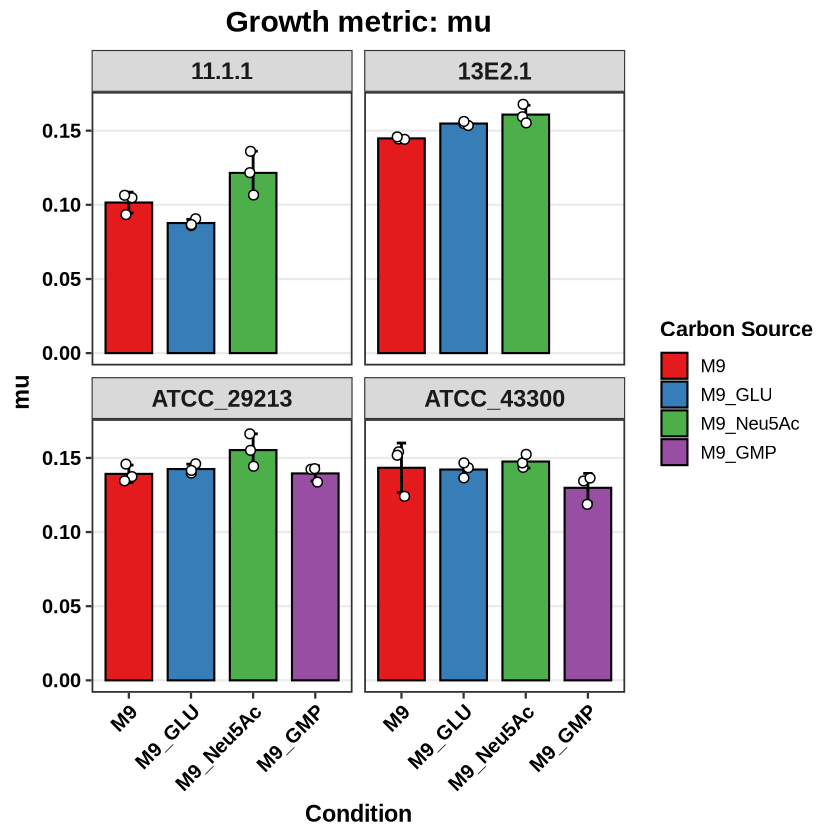

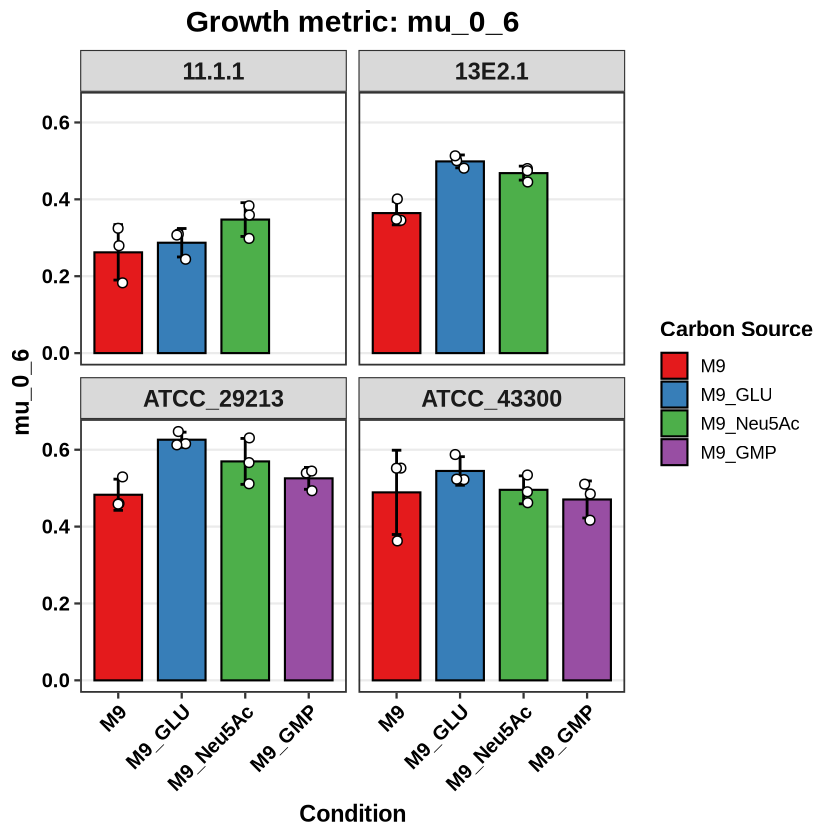

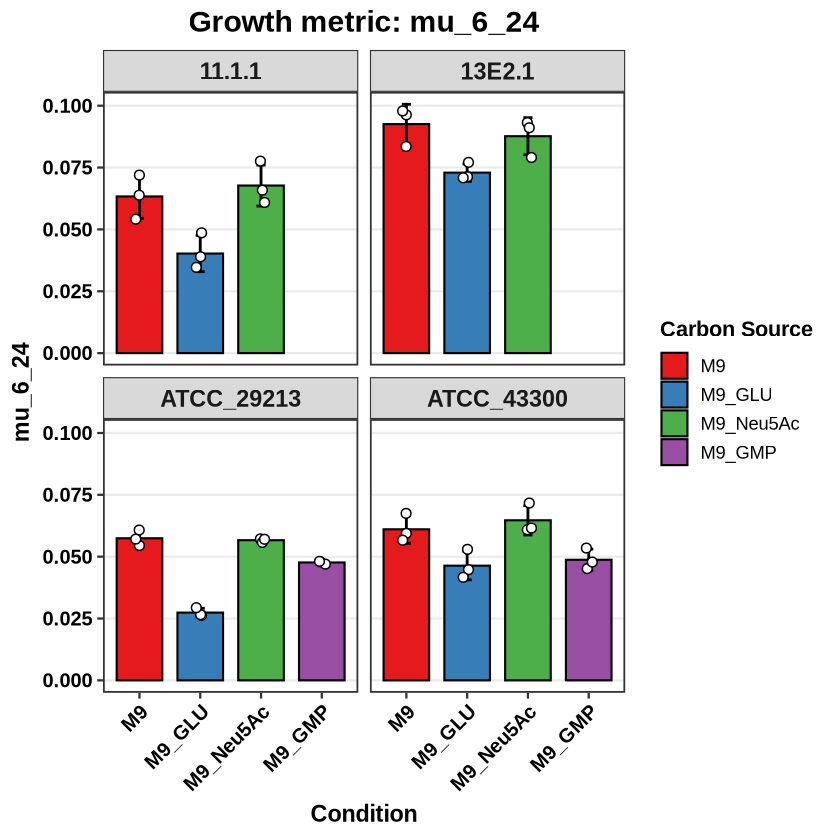

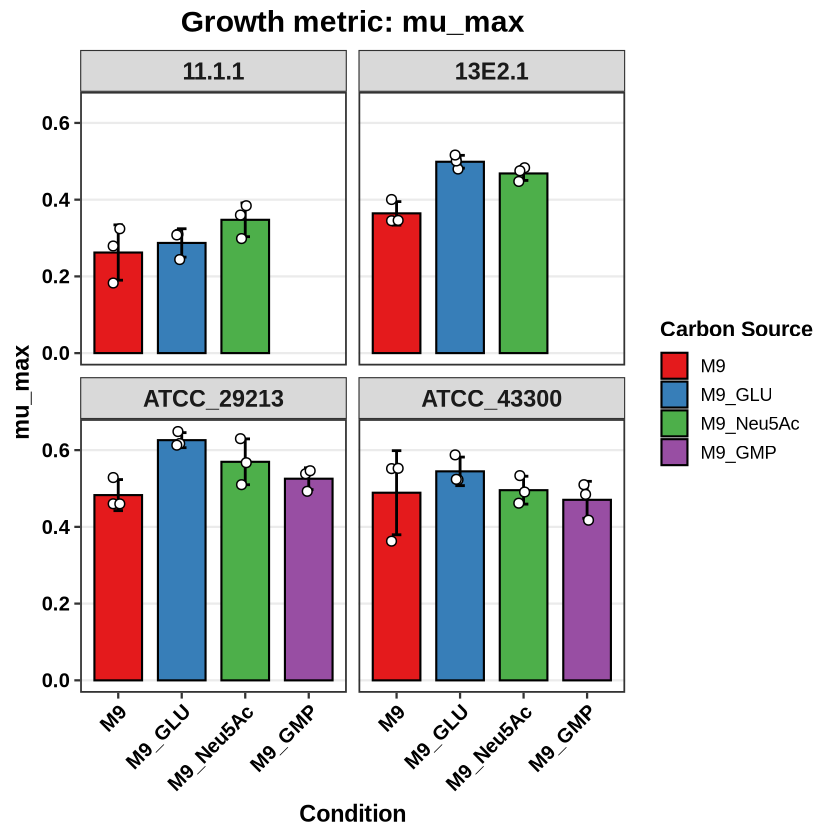

$mu

$mu_0_6

$mu_6_24

$mu_max

$delta_OD

$fold_change


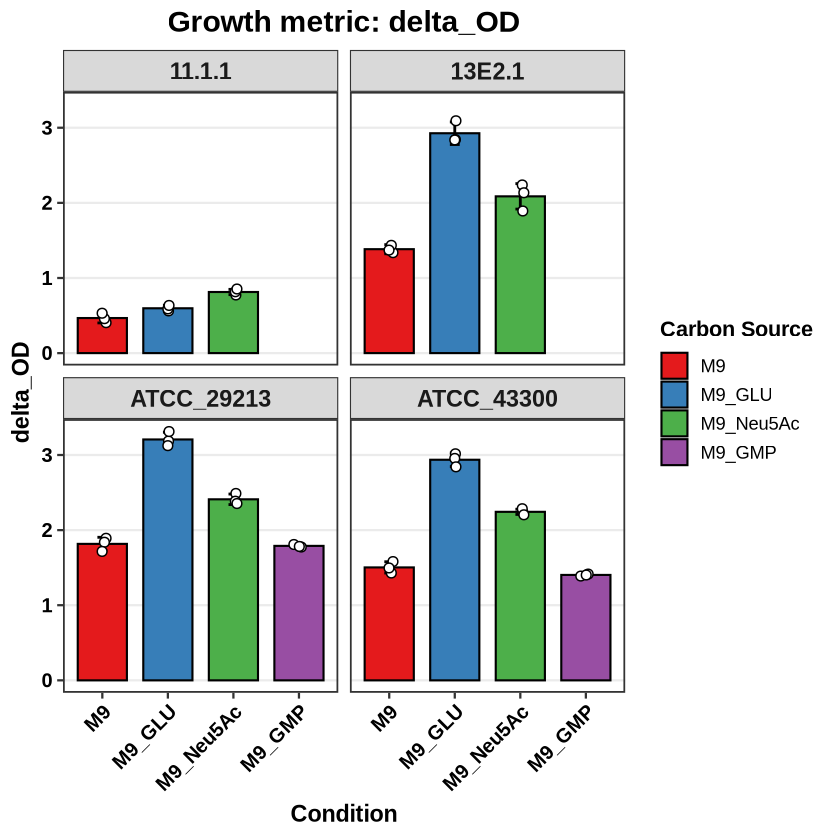

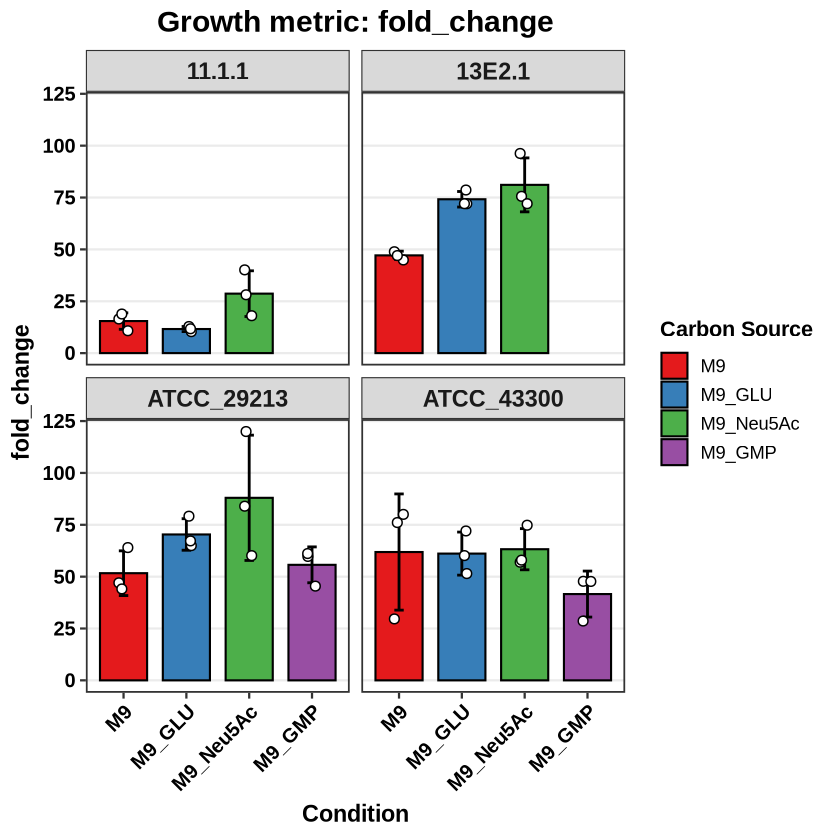

In [59]:
plots

In [62]:
ggsave("m9_aureus_vitor_test3006_deltaOD.png", plots$delta_OD)

Saving 6.67 x 6.67 in image


In [63]:
ggsave("m9_aureus_vitor_test3006_foldchange.png", plots$fold_change)

Saving 6.67 x 6.67 in image


In [65]:
# Explore relative growth to assess carbohydrate catabolism (tp 24h)

In [19]:
# Step 1 — extract endpoint (24h)
od_24h <- od_tp %>%
  filter(Time_hr == 24)
head(od_24h)

# 2. Step 2 — compute relative growth vs M9 (per strain + replicate)
od_rel <- od_24h %>%
  group_by(Strain) %>%
  mutate(
    m9_baseline = mean(OD600[Carbon == "M9"], na.rm = TRUE),
    rel_growth = OD600 / m9_baseline
  ) %>%
  ungroup()
head(od_rel)

# 3. Step 3 — summary stats
summary_od <- od_rel %>%
  group_by(Strain, Carbon) %>%
  summarise(
    mean_rel = mean(rel_growth, na.rm = TRUE),
    sd_rel   = sd(rel_growth, na.rm = TRUE),
    sem_rel  = sd(rel_growth) / sqrt(n()),
    n        = n(),
    .groups = "drop"
  )
head(summary_od)

Strain,Carbon,OD600,Time_hr,Replicate
<chr>,<chr>,<dbl>,<dbl>,<dbl>
ATCC_43300,M9_GLU,0.678,24,1
ATCC_43300,M9_GLU,0.589,24,2
ATCC_43300,M9_GLU,0.614,24,3
ATCC_43300,M9_SIA,0.125,24,1
ATCC_43300,M9_SIA,0.121,24,2
ATCC_43300,M9_SIA,0.125,24,3


Strain,Carbon,OD600,Time_hr,Replicate,m9_baseline,rel_growth
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ATCC_43300,M9_GLU,0.678,24,1,0.045,15.066667
ATCC_43300,M9_GLU,0.589,24,2,0.045,13.088889
ATCC_43300,M9_GLU,0.614,24,3,0.045,13.644444
ATCC_43300,M9_SIA,0.125,24,1,0.045,2.777778
ATCC_43300,M9_SIA,0.121,24,2,0.045,2.688889
ATCC_43300,M9_SIA,0.125,24,3,0.045,2.777778


Strain,Carbon,mean_rel,sd_rel,sem_rel,n
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<int>
ATCC_43300,M9,1.000000,0.43262050,0.24977356,3
ATCC_43300,M9_GLU,13.933333,1.02004599,0.58892383,3
ATCC_43300,M9_GMP,2.177778,0.19751543,0.11403559,3
ATCC_43300,M9_SIA,2.748148,0.05132002,0.02962963,3


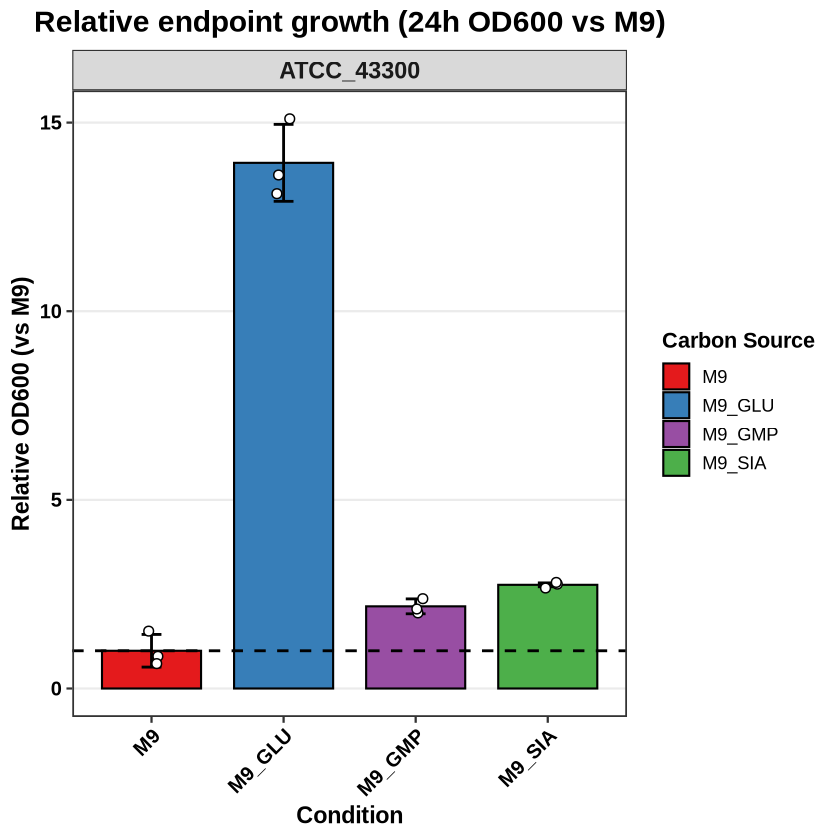

In [20]:
# Plot
library(ggplot2)

ggplot(summary_od, aes(x = Carbon, y = mean_rel, fill = Carbon)) +
  
  geom_col(
    color = "black",
    width = 0.75,
    linewidth = 0.6
  ) +
  
  geom_errorbar(
    aes(
      ymin = mean_rel - sd_rel,
      ymax = mean_rel + sd_rel
    ),
    width = 0.15,
    linewidth = 0.8
  ) +
  geom_hline(
  yintercept = 1,
  linetype = "dashed",
  linewidth = 0.8,
  color = "black"
) +
  geom_jitter(
    data = od_rel,
    aes(x = Carbon, y = rel_growth),
    width = 0.08,
    size = 2.3,
    shape = 21,
    fill = "white",
    color = "black"
  ) +
  
  facet_wrap(~Strain, ncol = 2) +
  
  scale_fill_manual(values = c(
    "M9" = "#E41A1C",
    "M9_GLU" = "#377EB8",
    "M9_SIA" = "#4DAF4A",
    "M9_GMP" = "#984EA3"
  )) +
  
  labs(
    title = "Relative endpoint growth (24h OD600 vs M9)",
    x = "Condition",
    y = "Relative OD600 (vs M9)",
    fill = "Carbon Source"
  ) +
  
  theme_bw(base_size = 14) +
  
  theme(
    plot.title = element_text(size = 18, face = "bold", hjust = 0.5),
    strip.text = element_text(size = 14, face = "bold"),
    axis.title = element_text(size = 14, face = "bold"),
    axis.text = element_text(size = 12, face = "bold", colour = "black"),
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.title = element_text(size = 13, face = "bold"),
    legend.text = element_text(size = 11),
    panel.grid.major.x = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_rect(linewidth = 1)
  )

In [12]:
ggsave("m9_anox_080726_relgrowth.png")

Saving 7 x 7 in image


In [21]:
# Welch t-test statistical test
library(dplyr)
library(purrr)

library(dplyr)
library(purrr)

stats_rel_growth <- function(data) {
  
  data <- data %>%
    mutate(Carbon = as.character(Carbon))  # 🔑 critical fix
  
  strains <- unique(data$Strain)
  carbs <- setdiff(unique(data$Carbon), "M9")
  
  expand.grid(Strain_loop = strains, Carbon_loop = carbs) %>%
    pmap_dfr(function(Strain_loop, Carbon_loop) {
      
      m9_vals <- data %>%
        filter(.data$Strain == Strain_loop,
               .data$Carbon == "M9") %>%
        pull(rel_growth)
      
      test_vals <- data %>%
        filter(.data$Strain == Strain_loop,
               .data$Carbon == Carbon_loop) %>%
        pull(rel_growth)
      
      if (length(m9_vals) < 2 || length(test_vals) < 2) {
        return(tibble(
          Strain = Strain_loop,
          Carbon = Carbon_loop,
          p_value = NA,
          test = "insufficient data"
        ))
      }
      
      test <- t.test(test_vals, m9_vals)
      
      tibble(
        Strain = Strain_loop,
        Carbon = Carbon_loop,
        mean_m9 = mean(m9_vals),
        mean_test = mean(test_vals),
        fold_change = mean(test_vals) / mean(m9_vals),
        diff = mean(test_vals) - mean(m9_vals),
        p_value = test$p.value,
        conf_low = test$conf.int[1],
        conf_high = test$conf.int[2],
        test = "welch_t_test"
      )
    }) %>%
    mutate(
      p_adj = p.adjust(p_value, method = "BH"),
      signif = case_when(
        is.na(p_adj) ~ NA_character_,
        p_adj < 0.001 ~ "***",
        p_adj < 0.01 ~ "**",
        p_adj < 0.05 ~ "*",
        TRUE ~ "ns"
      )
    )
}

# Run it 
## Welch’s t-test is recommended over Student’s t-test because it does not assume equal variance.
stats_od <- stats_rel_growth(od_rel)
stats_od

Strain,Carbon,mean_m9,mean_test,fold_change,diff,p_value,conf_low,conf_high,test,p_adj,signif
<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>
ATCC_43300,M9_GLU,1,13.933333,13.933333,12.933333,0.0005052913,10.7617837,15.104883,welch_t_test,0.001515874,**
ATCC_43300,M9_SIA,1,2.748148,2.748148,1.748148,0.0186535264,0.6938180,2.802478,welch_t_test,0.026755553,*
ATCC_43300,M9_GMP,1,2.177778,2.177778,1.177778,0.0267555526,0.2673772,2.088178,welch_t_test,0.026755553,*


In [23]:
gmp <- od_rel %>%
  filter(Strain == "ATCC_43300", Carbon == "M9_GMP") %>%
  pull(rel_growth)

sia <- od_rel %>%
  filter(Strain == "ATCC_43300", Carbon == "M9_SIA") %>%
  pull(rel_growth)

t.test(gmp, sia)


	Welch Two Sample t-test

data:  gmp and sia
t = -4.8409, df = 2.2688, p-value = 0.03106
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 -1.0238931 -0.1168477
sample estimates:
mean of x mean of y 
 2.177778  2.748148 
